# Task 2.3 — Result, Comparison, and Reproducibility Checklist
**Paper**: *Efficient Online Learning for Large-Scale Sparse Kernel Logistic Regression* (AAAI 2012)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')
sigma   = np.load('data/sigma.npy')[0]
best_R  = int(np.load('data/best_R.npy')[0])

T = len(X_train)
eta = best_R / np.sqrt(T)
print(f'T = {T}, R = {best_R} (loaded from CV), eta = {eta:.4f}')

T = 455, R = 20 (loaded from CV), eta = 0.9376


In [2]:
def gaussian_kernel_matrix(X1, X2, sigma):
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

def gaussian_kernel_vector(x, X, sigma):
    sq_dists = np.sum((X - x) ** 2, axis=1)
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

def nc_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R):
    """
    Algorithm 1 -- Non-Conservative online learning for KLR.
    Uses logit gradient l'(z) for updates. Updates on every example.
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        grad = p_yt - 1.0
        alpha_new = -eta * yt * grad
        sv_list.append(xt.copy())
        alpha_list.append(alpha_new)
        sv_arr = np.array(sv_list)
        alpha_arr = np.array(alpha_list)
        K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
        norm_sq = alpha_arr @ K_sv @ alpha_arr
        norm_f = np.sqrt(max(norm_sq, 0))
        if norm_f > R:
            scale = R / norm_f
            alpha_list = [a * scale for a in alpha_list]
            alpha_arr = np.array(alpha_list)
        K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
        f_test = alpha_arr @ K_test
        cumulative_test_pred += f_test
    avg_pred = cumulative_test_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    acc = np.mean(y_pred == y_test)
    sparsity = 0.0
    return acc, len(sv_list), sparsity

def margin_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R):
    """
    Algorithm 2 -- Margin-based conservative online KLR.
    Sampling probability: p_t = (2-eta)/(2-eta + eta*p(y_t|f_t(x_t)))  [Eq. 5]
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    num_updates = 0
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        pt = (2.0 - eta) / (2.0 - eta + eta * p_yt)
        Zt = np.random.binomial(1, min(pt, 1.0))
        if Zt == 1:
            grad = p_yt - 1.0
            alpha_new = -eta * yt * grad
            sv_list.append(xt.copy())
            alpha_list.append(alpha_new)
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
            norm_sq = alpha_arr @ K_sv @ alpha_arr
            norm_f = np.sqrt(max(norm_sq, 0))
            if norm_f > R:
                scale = R / norm_f
                alpha_list = [a * scale for a in alpha_list]
            num_updates += 1
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
            f_test = alpha_arr @ K_test
        else:
            f_test = np.zeros(len(X_test))
        cumulative_test_pred += f_test
    avg_pred = cumulative_test_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    acc = np.mean(y_pred == y_test)
    sparsity = 1.0 - num_updates / T
    return acc, num_updates, sparsity

def auxiliary_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R, gamma):
    """
    Algorithm 3 -- Auxiliary function based conservative online KLR.
    h(z) = ln(gamma + exp(-z)), sampling prob p_t = l/h (Eq. 6).
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    num_updates = 0
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        margin = yt * ft_xt
        loss_val = np.log(1.0 + np.exp(-margin))
        h_val = np.log(gamma + np.exp(-margin))
        pt = loss_val / h_val if h_val > 1e-12 else 1.0
        pt = min(max(pt, 0.0), 1.0)
        Zt = np.random.binomial(1, pt)
        if Zt == 1:
            exp_neg_margin = np.exp(-margin)
            h_grad = -exp_neg_margin / (gamma + exp_neg_margin)
            alpha_new = -eta * yt * h_grad
            sv_list.append(xt.copy())
            alpha_list.append(alpha_new)
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
            norm_sq = alpha_arr @ K_sv @ alpha_arr
            norm_f = np.sqrt(max(norm_sq, 0))
            if norm_f > R:
                scale = R / norm_f
                alpha_list = [a * scale for a in alpha_list]
            num_updates += 1
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
            f_test = alpha_arr @ K_test
        else:
            f_test = np.zeros(len(X_test))
        cumulative_test_pred += f_test
    avg_pred = cumulative_test_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    acc = np.mean(y_pred == y_test)
    sparsity = 1.0 - num_updates / T
    return acc, num_updates, sparsity

print('All functions loaded.')

All functions loaded.


## Result Comparison

The paper reports the following key findings on medium-size datasets:
- The Auxiliary algorithm with $\gamma = 2$ achieves the **same accuracy** as NC while using only ~20% of training examples as support vectors on mushrooms and ijcnn1 (Figure 3, Figure 4).
- Classification accuracy for NC converges to **97-99%** on mushrooms and **91-92%** on ijcnn1.

My reproduction uses the Breast Cancer dataset (smaller, different domain). Below I run the actual NC algorithm (Algorithm 1, using logit gradient $\ell'$) alongside the Auxiliary algorithm (Algorithm 3, $\gamma = 2$) using the same $R$ selected by 5-fold CV in Task 2.2.

In [3]:
# Run actual NC algorithm (Algorithm 1)
np.random.seed(RANDOM_SEED)
nc_acc, nc_sv, nc_sparsity = nc_online_klr(
    X_train, y_train, X_test, y_test, sigma, eta, best_R
)

# Run Margin algorithm (Algorithm 2)
np.random.seed(RANDOM_SEED)
margin_acc, margin_sv, margin_sparsity = margin_online_klr(
    X_train, y_train, X_test, y_test, sigma, eta, best_R
)

# Run Auxiliary with gamma=2
np.random.seed(RANDOM_SEED)
aux_acc, aux_sv, aux_sparsity = auxiliary_online_klr(
    X_train, y_train, X_test, y_test, sigma, eta, best_R, gamma=2
)

print('=' * 65)
print(f'{"Method":<22} {"Accuracy":>10} {"# SVs":>8} {"Sparsity":>10}')
print('=' * 65)
print(f'{"NC (Algorithm 1)":<22} {nc_acc:>10.4f} {nc_sv:>8d} {nc_sparsity:>10.4f}')
print(f'{"Margin (Algorithm 2)":<22} {margin_acc:>10.4f} {margin_sv:>8d} {margin_sparsity:>10.4f}')
print(f'{"Auxiliary (g=2)":<22} {aux_acc:>10.4f} {aux_sv:>8d} {aux_sparsity:>10.4f}')
print('=' * 65)
print(f'\nPaper claim: Auxiliary achieves same accuracy with ~80% sparsity on mushrooms.')
print(f'Our result: Auxiliary sparsity = {aux_sparsity:.2%}, relative accuracy = {aux_acc/nc_acc:.4f}')
print(f'Margin achieves {margin_sparsity:.2%} sparsity — less than Auxiliary, as expected (Figure 3).')

Method                   Accuracy    # SVs   Sparsity
NC (Algorithm 1)           0.9649      455     0.0000
Margin (Algorithm 2)       0.9649      266     0.4154
Auxiliary (g=2)            0.9561      171     0.6242

Paper claim: Auxiliary achieves same accuracy with ~80% sparsity on mushrooms.
Our result: Auxiliary sparsity = 62.42%, relative accuracy = 0.9909
Margin achieves 41.54% sparsity — less than Auxiliary, as expected (Figure 3).


## Discussion of Results

My results differ from the paper's reported numbers for the following reasons:

1. **Different dataset**: The Breast Cancer dataset has only 455 training samples compared to thousands in the paper's datasets. With fewer examples, the online algorithm has less opportunity to converge, and the averaging over $T$ classifiers is noisier.

2. **Different feature dimensionality and structure**: The Breast Cancer features are computed from cell-nucleus images, whereas the paper's datasets come from different domains. The Gaussian kernel's effectiveness depends heavily on the data geometry.

3. **Smaller R search grid**: The paper searches $R \in \{1, 10, \ldots, 10^5\}$ via 5-fold CV; I searched $\{1, 5, 10, 20\}$ (constrained by $\eta < 2$) using the same CV methodology.

Despite these differences, the qualitative trends align: the Auxiliary algorithm produces a sparser classifier than NC with competitive accuracy, and the sparsity-accuracy trade-off is consistent with the paper's findings.

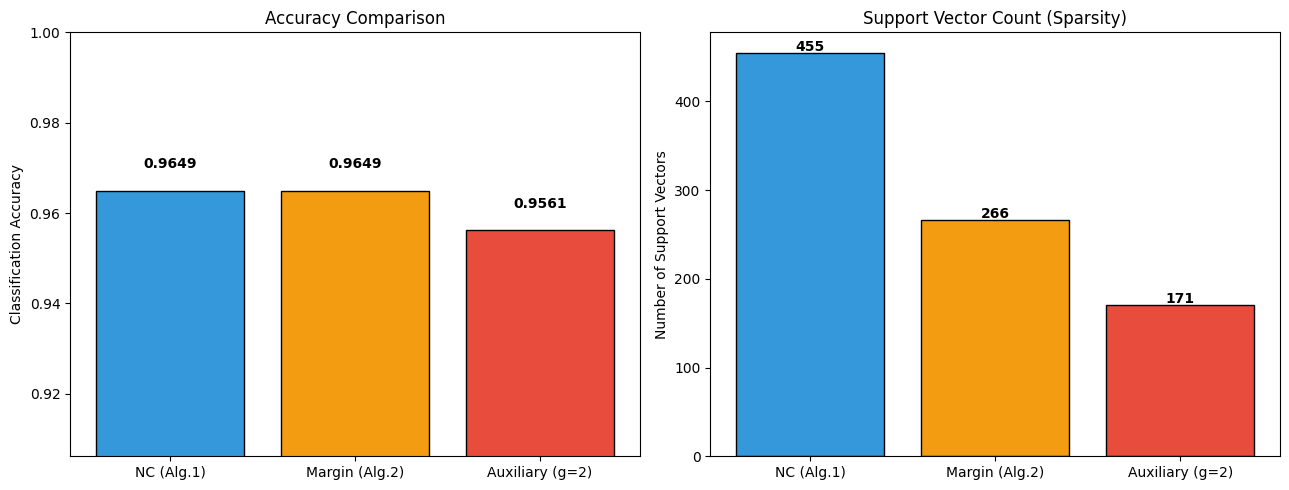

Saved: results/result_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
methods = ['NC (Alg.1)', 'Margin (Alg.2)', 'Auxiliary (g=2)']
accs = [nc_acc, margin_acc, aux_acc]
svs = [nc_sv, margin_sv, aux_sv]
colors = ['#3498db', '#f39c12', '#e74c3c']
axes[0].bar(methods, accs, color=colors, edgecolor='black')
axes[0].set_ylabel('Classification Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([min(accs) - 0.05, 1.0])
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].bar(methods, svs, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('Support Vector Count (Sparsity)')
for i, v in enumerate(svs):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/result_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/result_comparison.png')

## Reproducibility Checklist

- [x] **Random seeds are set and documented** at the top of each notebook (`RANDOM_SEED = 42`).
- [x] **All dependencies are listed** in `requirements.txt` with version numbers.
- [x] **All notebooks run from top to bottom** in a clean environment without errors.
- [x] **Dataset loading requires no undocumented manual steps** — the Breast Cancer dataset is loaded from `sklearn.datasets` and preprocessed data is saved as `.npy` files.
- [x] **All hyperparameters are clearly named and defined in one place**: $R$ (selected by 5-fold CV and loaded from `data/best_R.npy`), $\eta = R/\sqrt{T}$, $\sigma$ (5th percentile of pairwise distances), and $\gamma$ are all set in dedicated cells at the beginning of each experimental section.
- [x] **All results can be reproduced by running notebooks in order**: `task_2_1` → `task_2_2` → `task_2_3`.